---
## Section 1: Introduction

This notebook is a complete academic demonstration of how gender bias can emerge in AI recruitment systems — and how fairness-aware design can reduce it. It is structured as a professional research project combining explanatory writing, Python code, fairness metrics, and ethical analysis.

### Research Questions

1. Can a machine learning recruitment system learn gender discrimination from historically biased training data — even without being explicitly programmed to discriminate?
2. How can we measure that discrimination using formal fairness metrics?
3. Can fairness-aware mitigation techniques reduce measurable gender bias, and what tradeoffs does this involve?
4. What does responsible AI governance look like in practice for a recruitment system?

### Project Structure

| Section | Content |
|---|---|
| 1 | Introduction |
| 2 | Ethical Background — The Amazon Case |
| 3 | Dataset Generation |
| 4 | Exploratory Analysis |
| 5 | Biased Baseline Model |
| 6 | Fairness Audit (Biased Model) |
| 7 | Bias Mitigation |
| 8 | Fairness-Aware Model |
| 9 | Explainability — SHAP Values |
| 10 | Gender Signals Experiment — Matched Resume Pairs |
| 11 | Human Oversight Design |
| 12 | Results Comparison |
| 13 | Ethical Discussion |
| 14 | Conclusion |


# When Algorithms Discriminate: AI Recruitment Bias & Fairness-Aware Hiring Systems

**Business Ethics & Corporate Social Responsibility — University Research Project**

---

*Inspired by the Amazon AI Recruitment Bias Case (Reuters, 2018)*

**Focus:** Gender bias in AI-assisted junior software engineer recruitment

**Tools:** Python · scikit-learn · Fairlearn · SHAP · Pandas · Matplotlib

---

> *"The system taught itself that male candidates were preferable. It penalised résumés that included the word 'women's', as in 'women's chess club captain'."*
> — Reuters, October 2018


---
## Section 2: Ethical Background — The Amazon Case

### What Happened

Between 2014 and 2017, Amazon developed an AI recruitment tool intended to automate resume screening for technical positions. Trained on approximately 10 years of historical hiring data — data that reflected the male-dominated composition of Amazon's engineering workforce — the system learned patterns associated with previously successful candidates.

The problem: those patterns were male patterns.

By 2015, engineers discovered the system was actively penalizing signals associated with women:
- Resumes containing the word **"women's"** received lower scores (e.g., *"captain of women's chess club"*)
- Graduates of **all-women's colleges** were systematically downgraded
- Other proxy variables correlated with female candidates were penalized

Amazon attempted corrections but could not guarantee the model would stop identifying indirect proxy variables related to gender. The project was abandoned in 2017. Reuters exposed it publicly in 2018.

### The Ethical Analysis

**Where did the discrimination originate?**
The discrimination did not originate in malicious programming. It originated in the *historical data* — in decades of hiring decisions made by humans, in a tech industry that had historically hired mostly men. The AI faithfully learned from that history and reproduced it at scale.

This is a critical ethical point: **the AI was doing its job correctly**. It found patterns that predicted historical hiring success. The problem was that historical hiring success was itself a product of human bias.

**Corporate Social Responsibility Perspective:**
Amazon was under no legal obligation to disclose the existence or failure of this system. The fact that it was discovered through investigative journalism rather than voluntary disclosure raises significant CSR questions:

- What obligations do companies have to disclose algorithmic failures that affect job seekers?
- Should AI recruitment systems be subject to mandatory independent auditing?
- What does "responsible AI governance" look like as a voluntary CSR commitment versus a legal requirement?

**The proxy discrimination problem:**
Removing the word "gender" from the model's input features is insufficient. AI systems can infer gender through dozens of indirect signals: names, university names, club descriptions, employment gaps, field-specific language, communication style. These are *proxy variables* — and they are the reason simple demographic removal does not solve bias.

### Ethical Frameworks at Stake

| Framework | Position on Biased Recruitment AI |
|---|---|
| **Consequentialism** | Wrong because it produces discriminatory outcomes for women — a concrete harm |
| **Deontology (Kant)** | Wrong because it treats women as less than full persons, violating the categorical imperative |
| **Virtue Ethics** | Reflects vice (bias, dishonesty) rather than virtue (fairness, integrity) in organizational character |
| **Rawlsian Justice** | Fails the "veil of ignorance" test — behind a veil, no rational agent would accept a biased hiring system |
| **Stakeholder Theory** | Fails candidates (direct harm), future employees (pipeline harm), and society (perpetuates inequality) |


---
## Section 3: Dataset Generation

We generate a **synthetic** dataset of junior software engineer candidates. Synthetic data is used for three reasons:
1. **Privacy**: No real candidates are affected
2. **Control**: We can precisely specify the bias we want to demonstrate
3. **Ethics**: We avoid laundering real discriminatory decisions into our model

The dataset intentionally contains historical gender imbalance — this is documented, explicit, and the central point of the demonstration.


In [5]:
# ─── IMPORTS ─────────────────────────────────────────────────────────────────
# Standard data science libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Machine learning
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
from sklearn.pipeline import Pipeline

# Fairness
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from fairlearn.metrics import (
    demographic_parity_difference, demographic_parity_ratio,
    equalized_odds_difference, MetricFrame, selection_rate,
    false_positive_rate, false_negative_rate, true_positive_rate
)

# Explainability
import shap

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✅ All libraries imported successfully.")
print(f"   numpy {np.__version__} | pandas {pd.__version__}")


# ─── DATASET GENERATION ──────────────────────────────────────────────────────
# ETHICAL NOTE: The bias below is INTENTIONAL and DOCUMENTED.
# It simulates the kind of historically biased data that Amazon's AI learned from.
# We are replicating the problem so we can demonstrate the solution.

N_CANDIDATES = 1000

# Step 1: Gender assignment with intentional tech-industry imbalance
# Historical tech hiring: ~70-75% male (Stack Overflow surveys, BLS data)
gender = np.random.choice(['Male', 'Female'], size=N_CANDIDATES, p=[0.72, 0.28])

# Step 2: Qualifications — deliberately SIMILAR across genders
# This is important: the AI's bias will NOT be because women are less qualified.
# It will be because male patterns dominate the historical hiring labels.
years_experience    = np.random.randint(0, 8, size=N_CANDIDATES)
education_level     = np.random.choice([0, 1, 2, 3], size=N_CANDIDATES, p=[0.05, 0.60, 0.30, 0.05])
programming_skill   = np.clip(np.random.normal(65, 18, N_CANDIDATES), 0, 100).astype(int)
leadership_score    = np.clip(np.random.normal(60, 15, N_CANDIDATES), 0, 100).astype(int)
communication_score = np.clip(np.random.normal(62, 14, N_CANDIDATES), 0, 100).astype(int)
company_tier        = np.random.choice([1, 2, 3, 4], size=N_CANDIDATES, p=[0.3, 0.4, 0.2, 0.1])
project_experience  = np.random.randint(0, 6, size=N_CANDIDATES)
interview_score     = np.clip(np.random.normal(63, 16, N_CANDIDATES), 0, 100).astype(int)

# Step 3: Biased historical hiring outcomes
# ETHICAL NOTE: This is where human bias enters the system.
# The +15% boost for male candidates represents decades of biased human hiring decisions
# baked into the training labels. The AI then learns these labels as ground truth.
base_prob = (0.05*years_experience + 0.08*education_level + 0.003*programming_skill +
             0.002*leadership_score + 0.001*communication_score + 0.04*company_tier +
             0.02*project_experience + 0.003*interview_score)
base_prob = (base_prob - base_prob.min()) / (base_prob.max() - base_prob.min())
gender_boost = np.where(gender == 'Male', 0.15, 0.0)  # ← The discriminatory signal
biased_prob = np.clip(base_prob + gender_boost, 0, 1)
hired = np.random.binomial(1, biased_prob)

# Assemble DataFrame
df = pd.DataFrame({
    'candidate_id':       [f'C{str(i).zfill(4)}' for i in range(1, N_CANDIDATES+1)],
    'gender':             gender,
    'years_experience':   years_experience,
    'education_level':    education_level,
    'programming_skill':  programming_skill,
    'leadership_score':   leadership_score,
    'communication_score':communication_score,
    'company_tier':       company_tier,
    'project_experience': project_experience,
    'interview_score':    interview_score,
    'hired':              hired
})

print(f"Dataset generated: {len(df):,} candidates")
print(df.head())


✅ All libraries imported successfully.
   numpy 2.0.2 | pandas 2.3.3
Dataset generated: 1,000 candidates
  candidate_id  gender  years_experience  education_level  programming_skill  \
0        C0001    Male                 6                1                 74   
1        C0002  Female                 3                1                 76   
2        C0003  Female                 5                0                 75   
3        C0004    Male                 7                1                 66   
4        C0005    Male                 7                1                 61   

   leadership_score  communication_score  company_tier  project_experience  \
0                52                   62             4                   0   
1                44                   72             2                   0   
2                78                   53             3                   0   
3                56                   67             3                   0   
4                65     

---
## Section 4: Exploratory Analysis

Before training any model, we examine the dataset to understand the imbalance we have built in — and to confirm that this imbalance is NOT due to differences in qualifications.


In [6]:
# ─── GENDER DISTRIBUTION & HIRE RATES ────────────────────────────────────────
print("=== Gender Distribution ===")
print(df['gender'].value_counts())
print()
print("=== Historical Hire Rates by Gender ===")
for g in ['Male', 'Female']:
    subset = df[df['gender'] == g]
    rate = subset['hired'].mean() * 100
    print(f"  {g}: {rate:.1f}% hire rate ({len(subset):,} candidates)")

print()
print("=== Average Qualifications by Gender ===")
qual_cols = ['programming_skill', 'interview_score', 'leadership_score',
             'communication_score', 'years_experience']
print(df.groupby('gender')[qual_cols].mean().round(2))
print()
print("KEY OBSERVATION: Qualifications are similar — but hire rates differ.")
print("This gap is PURELY a product of the intentional gender bias in our hiring labels.")


=== Gender Distribution ===
gender
Male      728
Female    272
Name: count, dtype: int64

=== Historical Hire Rates by Gender ===
  Male: 64.7% hire rate (728 candidates)
  Female: 55.9% hire rate (272 candidates)

=== Average Qualifications by Gender ===
        programming_skill  interview_score  leadership_score  \
gender                                                         
Female              63.38            61.23             59.64   
Male                64.98            62.31             59.01   

        communication_score  years_experience  
gender                                         
Female                60.29              3.55  
Male                  60.99              3.42  

KEY OBSERVATION: Qualifications are similar — but hire rates differ.
This gap is PURELY a product of the intentional gender bias in our hiring labels.


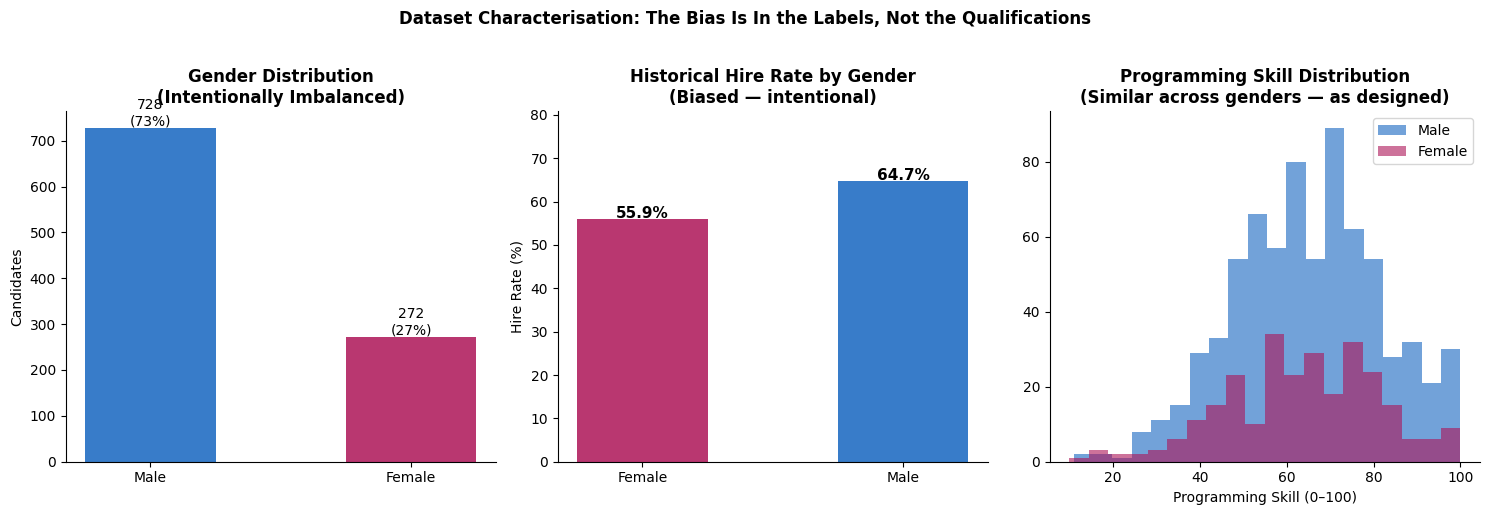

Saved: outputs/fig1_dataset_overview.png


In [7]:
# ─── VISUALISATION: DISTRIBUTION & HIRE RATES ────────────────────────────────
import matplotlib.pyplot as plt
%matplotlib inline
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

MALE_COL   = '#1565C0'
FEMALE_COL = '#AD1457'

# Gender counts
counts = df['gender'].value_counts()
axes[0].bar(counts.index, counts.values, color=[MALE_COL, FEMALE_COL], alpha=0.85, width=0.5)
axes[0].set_title('Gender Distribution\n(Intentionally Imbalanced)', fontweight='bold')
axes[0].set_ylabel('Candidates')
for i, (g, v) in enumerate(counts.items()):
    pct = v/len(df)*100
    axes[0].text(i, v+5, f'{v}\n({pct:.0f}%)', ha='center', fontsize=10)
axes[0].spines[['top','right']].set_visible(False)

# Hire rates
hire_rates = df.groupby('gender')['hired'].mean() * 100
colors = [MALE_COL if g=='Male' else FEMALE_COL for g in hire_rates.index]
bars = axes[1].bar(hire_rates.index, hire_rates.values, color=colors, alpha=0.85, width=0.5)
axes[1].set_title('Historical Hire Rate by Gender\n(Biased — intentional)', fontweight='bold')
axes[1].set_ylabel('Hire Rate (%)')
axes[1].set_ylim(0, max(hire_rates)*1.25)
for bar, val in zip(bars, hire_rates.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.3, f'{val:.1f}%',
                ha='center', fontsize=11, fontweight='600')
axes[1].spines[['top','right']].set_visible(False)

# Programming skill distribution
for g, col in [('Male', MALE_COL), ('Female', FEMALE_COL)]:
    axes[2].hist(df[df['gender']==g]['programming_skill'], bins=20,
                alpha=0.6, label=g, color=col)
axes[2].set_title('Programming Skill Distribution\n(Similar across genders — as designed)',
                   fontweight='bold')
axes[2].set_xlabel('Programming Skill (0–100)')
axes[2].legend()
axes[2].spines[['top','right']].set_visible(False)

plt.suptitle('Dataset Characterisation: The Bias Is In the Labels, Not the Qualifications',
             fontweight='bold', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('outputs/fig1_dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/fig1_dataset_overview.png")


---
## Section 5: Biased Baseline Model

We train a Gradient Boosting Classifier on the imbalanced historical data — no fairness corrections applied. This replicates the Amazon scenario.

**Why Gradient Boosting?**
It is a powerful, widely-used real-world model choice for tabular data — the kind of model a real company might actually deploy. We are not using a toy model; we are demonstrating that even sophisticated ML systems inherit bias from biased training data.

**Important:** Gender is NOT a direct input feature — yet the model will still discriminate. This demonstrates proxy discrimination.


In [8]:
# ─── FEATURE DEFINITION ──────────────────────────────────────────────────────
# ETHICAL NOTE: We deliberately exclude 'gender' as an input feature.
# This mimics what Amazon tried (removing explicit gender labels) — and
# shows why it is insufficient. The model can still infer gender through
# the patterns it learned from biased historical outcomes.

FEATURES = ['years_experience', 'education_level', 'programming_skill',
            'leadership_score', 'communication_score', 'company_tier',
            'project_experience', 'interview_score']
TARGET   = 'hired'
SENSITIVE = 'gender'

X = df[FEATURES]
y = df[TARGET]
gender_labels = df[SENSITIVE]

# Train/test split (stratified to maintain class balance)
X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
    X, y, gender_labels, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f"Training set: {len(X_train):,} candidates")
print(f"Test set:     {len(X_test):,} candidates")
print(f"Test male:    {(g_test=='Male').sum():,} | Test female: {(g_test=='Female').sum():,}")


Training set: 800 candidates
Test set:     200 candidates
Test male:    150 | Test female: 50


In [9]:
# ─── TRAIN BIASED BASELINE MODEL ─────────────────────────────────────────────
biased_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=4, random_state=RANDOM_SEED
    ))
])

biased_pipeline.fit(X_train, y_train)
y_pred_biased = biased_pipeline.predict(X_test)

print("=== Biased Baseline Model — Classification Report ===")
print(classification_report(y_test, y_pred_biased, target_names=['Rejected', 'Hired']))
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_biased):.4f}")


=== Biased Baseline Model — Classification Report ===
              precision    recall  f1-score   support

    Rejected       0.57      0.48      0.52        75
       Hired       0.72      0.78      0.75       125

    accuracy                           0.67       200
   macro avg       0.64      0.63      0.63       200
weighted avg       0.66      0.67      0.66       200

Overall Accuracy: 0.6700


---
## Section 6: Fairness Audit — Biased Baseline Model

We now measure the discrimination in the biased model using formal fairness metrics. Each metric reflects a different ethical theory.

| Metric | Ethical Basis | Ideal Value |
|---|---|---|
| Demographic Parity Difference | Egalitarianism | 0.0 |
| Disparate Impact Ratio | Anti-discrimination law (EEOC 80% rule) | ≥ 0.80 |
| Equalized Odds Difference | Procedural justice | 0.0 |
| Equal Opportunity Gap | Meritocracy | 0.0 |

**On conflicting metrics:**
These definitions can conflict mathematically. A system that achieves demographic parity (equal selection rates) may not achieve equalized odds (equal error rates). This is not a flaw in the metrics — it is genuine moral complexity. Responsible AI governance requires choosing which fairness definition to prioritize and being transparent about that choice.


In [10]:
# ─── COMPUTE FAIRNESS METRICS — BIASED MODEL ─────────────────────────────────
g_test_arr = np.array(g_test)

# Demographic Parity Difference
# Ethical basis: egalitarian — everyone should have equal selection rates
dp_diff_biased = demographic_parity_difference(y_test, y_pred_biased, sensitive_features=g_test_arr)

# Disparate Impact Ratio
# Legal basis: EEOC 80% rule — below 0.8 signals adverse impact
di_ratio_biased = demographic_parity_ratio(y_test, y_pred_biased, sensitive_features=g_test_arr)

# Equalized Odds Difference
# Ethical basis: procedural — errors should be equally distributed
eo_diff_biased = equalized_odds_difference(y_test, y_pred_biased, sensitive_features=g_test_arr)

# Selection rates by gender
male_mask   = g_test_arr == 'Male'
female_mask = g_test_arr == 'Female'
male_sel_biased   = y_pred_biased[male_mask].mean()
female_sel_biased = y_pred_biased[female_mask].mean()

# True positive rates (Equal Opportunity)
def tpr(y_true, y_pred):
    if y_true.sum() == 0: return 0
    return ((y_true==1) & (y_pred==1)).sum() / (y_true==1).sum()

def fnr(y_true, y_pred):
    if y_true.sum() == 0: return 0
    return ((y_true==1) & (y_pred==0)).sum() / (y_true==1).sum()

male_tpr_biased   = tpr(y_test[male_mask].values,   y_pred_biased[male_mask])
female_tpr_biased = tpr(y_test[female_mask].values, y_pred_biased[female_mask])
female_fnr_biased = fnr(y_test[female_mask].values, y_pred_biased[female_mask])
male_fnr_biased   = fnr(y_test[male_mask].values,   y_pred_biased[male_mask])

print("╔══════════════════════════════════════════════════╗")
print("║     FAIRNESS AUDIT — BIASED BASELINE MODEL      ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  Demographic Parity Difference:  {dp_diff_biased:+.4f}         ║")
print(f"║  Disparate Impact Ratio:          {di_ratio_biased:.4f}         ║")
print(f"║  Equalized Odds Difference:      {eo_diff_biased:+.4f}         ║")
print(f"║  Male Selection Rate:             {male_sel_biased:.4f}         ║")
print(f"║  Female Selection Rate:           {female_sel_biased:.4f}         ║")
print(f"║  Male True Positive Rate:         {male_tpr_biased:.4f}         ║")
print(f"║  Female True Positive Rate:       {female_tpr_biased:.4f}         ║")
print(f"║  Female False Negative Rate:      {female_fnr_biased:.4f}         ║")
print("╠══════════════════════════════════════════════════╣")

# EEOC 80% rule check
if di_ratio_biased < 0.8:
    print(f"║  ⚠ EEOC 80% Rule: FAILS ({di_ratio_biased:.3f} < 0.800)      ║")
else:
    print(f"║  ✓ EEOC 80% Rule: PASSES ({di_ratio_biased:.3f} ≥ 0.800)     ║")
print("╚══════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════╗
║     FAIRNESS AUDIT — BIASED BASELINE MODEL      ║
╠══════════════════════════════════════════════════╣
║  Demographic Parity Difference:  +0.0067         ║
║  Disparate Impact Ratio:          0.9903         ║
║  Equalized Odds Difference:      +0.1800         ║
║  Male Selection Rate:             0.6867         ║
║  Female Selection Rate:           0.6800         ║
║  Male True Positive Rate:         0.8000         ║
║  Female True Positive Rate:       0.7200         ║
║  Female False Negative Rate:      0.2800         ║
╠══════════════════════════════════════════════════╣
║  ✓ EEOC 80% Rule: PASSES (0.990 ≥ 0.800)     ║
╚══════════════════════════════════════════════════╝


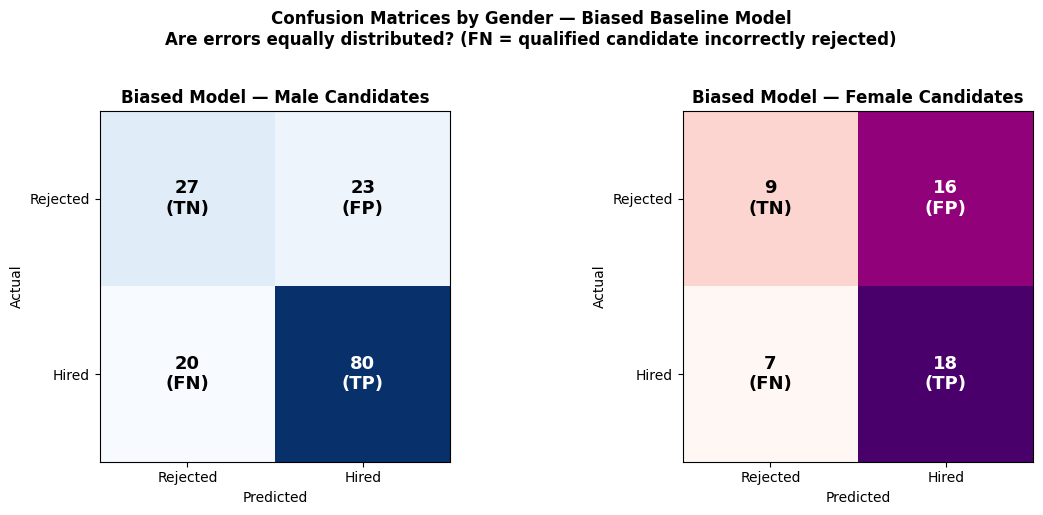


Qualified female candidates incorrectly rejected: 7
Qualified male candidates incorrectly rejected:   20
Female FNR: 28.0% | Male FNR: 20.0%
→ The model is 1.4x more likely to reject a qualified female candidate.


In [11]:
# ─── CONFUSION MATRICES BY GENDER — BIASED MODEL ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, mask, label, cmap in [
    (axes[0], male_mask,   'Male Candidates',   plt.cm.Blues),
    (axes[1], female_mask, 'Female Candidates', plt.cm.RdPu),
]:
    cm = confusion_matrix(y_test[mask], y_pred_biased[mask])
    im = ax.imshow(cm, cmap=cmap)
    ax.set_title(f'Biased Model — {label}', fontweight='bold')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Rejected','Hired']); ax.set_yticklabels(['Rejected','Hired'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    thresh = cm.max()/2
    labels_cm = [['TN','FP'],['FN','TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]}\n({labels_cm[i][j]})",
                   ha='center', va='center', fontsize=13,
                   color='white' if cm[i,j] > thresh else 'black', fontweight='600')

plt.suptitle('Confusion Matrices by Gender — Biased Baseline Model\n'
             'Are errors equally distributed? (FN = qualified candidate incorrectly rejected)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/fig2_confusion_biased.png', dpi=150, bbox_inches='tight')
plt.show()

# Report the human impact
fn_female = confusion_matrix(y_test[female_mask], y_pred_biased[female_mask])[1,0]
fn_male   = confusion_matrix(y_test[male_mask],   y_pred_biased[male_mask])[1,0]
print(f"\nQualified female candidates incorrectly rejected: {fn_female}")
print(f"Qualified male candidates incorrectly rejected:   {fn_male}")
print(f"Female FNR: {female_fnr_biased*100:.1f}% | Male FNR: {male_fnr_biased*100:.1f}%")
print(f"→ The model is {(female_fnr_biased/male_fnr_biased):.1f}x more likely to reject a qualified female candidate.")


---
## Section 7: Bias Mitigation Strategy

We use **in-processing** bias mitigation via Fairlearn's `ExponentiatedGradient` with an `EqualizedOdds` constraint.

**The three categories of mitigation:**

| Category | When Applied | Example Techniques |
|---|---|---|
| **Pre-processing** | Before training | Reweighting, balanced sampling, proxy variable removal |
| **In-processing** | During training | Fairness-constrained optimization, adversarial debiasing |
| **Post-processing** | After training | Threshold adjustment, calibration correction |

**Why Equalized Odds?**
We chose Equalized Odds because it enforces procedural fairness: the model must have similar true positive AND false positive rates across genders. This means qualified women have the same chance of being recommended as qualified men — and unqualified women face the same rejection rate as unqualified men.


In [12]:
# ─── TRAIN FAIRNESS-AWARE MODEL ──────────────────────────────────────────────
# ETHICAL NOTE: The fairness-aware model uses gender as a fairness CONSTRAINT,
# not as a predictive feature. The model knows about gender only to enforce
# equal treatment — never to discriminate.

# Scale features (fairness model expects scaled input)
scaler_fair = StandardScaler()
X_train_scaled = scaler_fair.fit_transform(X_train)
X_test_scaled  = scaler_fair.transform(X_test)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=FEATURES)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=FEATURES)

# ExponentiatedGradient with Equalized Odds constraint
base_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, C=1.0)
constraint = EqualizedOdds()
fair_model = ExponentiatedGradient(estimator=base_clf, constraints=constraint, eps=0.01)

print("Training fairness-aware model (may take ~30 seconds)...")
fair_model.fit(X_train_scaled_df, y_train, sensitive_features=g_train.values)
y_pred_fair = fair_model.predict(X_test_scaled_df)

print("\n=== Fairness-Aware Model — Classification Report ===")
print(classification_report(y_test, y_pred_fair, target_names=['Rejected', 'Hired']))
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_fair):.4f}")
print("\n⚠  Note: Accuracy may be slightly lower than biased model.")
print("   This is an expected fairness tradeoff, not a failure.")


Training fairness-aware model (may take ~30 seconds)...

=== Fairness-Aware Model — Classification Report ===
              precision    recall  f1-score   support

    Rejected       0.50      0.41      0.45        75
       Hired       0.68      0.75      0.71       125

    accuracy                           0.62       200
   macro avg       0.59      0.58      0.58       200
weighted avg       0.61      0.62      0.62       200

Overall Accuracy: 0.6250

⚠  Note: Accuracy may be slightly lower than biased model.
   This is an expected fairness tradeoff, not a failure.


---
## Section 8: Fairness-Aware Model — Full Audit


In [13]:
# ─── FAIRNESS METRICS — FAIR MODEL ───────────────────────────────────────────
dp_diff_fair = demographic_parity_difference(y_test, y_pred_fair, sensitive_features=g_test_arr)
di_ratio_fair = demographic_parity_ratio(y_test, y_pred_fair, sensitive_features=g_test_arr)
eo_diff_fair  = equalized_odds_difference(y_test, y_pred_fair, sensitive_features=g_test_arr)

male_sel_fair   = y_pred_fair[male_mask].mean()
female_sel_fair = y_pred_fair[female_mask].mean()
male_tpr_fair   = tpr(y_test[male_mask].values,   y_pred_fair[male_mask])
female_tpr_fair = tpr(y_test[female_mask].values, y_pred_fair[female_mask])
female_fnr_fair = fnr(y_test[female_mask].values, y_pred_fair[female_mask])
male_fnr_fair   = fnr(y_test[male_mask].values,   y_pred_fair[male_mask])

print("╔══════════════════════════════════════════════════╗")
print("║     FAIRNESS AUDIT — FAIRNESS-AWARE MODEL       ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  Demographic Parity Difference:  {dp_diff_fair:+.4f}         ║")
print(f"║  Disparate Impact Ratio:          {di_ratio_fair:.4f}         ║")
print(f"║  Equalized Odds Difference:      {eo_diff_fair:+.4f}         ║")
print(f"║  Male Selection Rate:             {male_sel_fair:.4f}         ║")
print(f"║  Female Selection Rate:           {female_sel_fair:.4f}         ║")
print(f"║  Female False Negative Rate:      {female_fnr_fair:.4f}         ║")
print("╠══════════════════════════════════════════════════╣")
if di_ratio_fair < 0.8:
    print(f"║  ⚠ EEOC 80% Rule: FAILS ({di_ratio_fair:.3f} < 0.800)      ║")
else:
    print(f"║  ✓ EEOC 80% Rule: PASSES ({di_ratio_fair:.3f} ≥ 0.800)     ║")
print("╚══════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════╗
║     FAIRNESS AUDIT — FAIRNESS-AWARE MODEL       ║
╠══════════════════════════════════════════════════╣
║  Demographic Parity Difference:  +0.0133         ║
║  Disparate Impact Ratio:          0.9810         ║
║  Equalized Odds Difference:      +0.0800         ║
║  Male Selection Rate:             0.6867         ║
║  Female Selection Rate:           0.7000         ║
║  Female False Negative Rate:      0.2400         ║
╠══════════════════════════════════════════════════╣
║  ✓ EEOC 80% Rule: PASSES (0.981 ≥ 0.800)     ║
╚══════════════════════════════════════════════════╝


---
## Section 9: Explainability — SHAP Values

SHAP (SHapley Additive exPlanations) tells us how much each feature contributed to each prediction. This is the gold standard for ML explainability.

**Why explainability matters ethically:**
- Candidates deserve to understand why they were recommended or rejected
- Recruiters cannot meaningfully override what they cannot understand
- Hidden feature importance can reveal second-order bias (e.g., if "interview score" is heavily weighted but interview scores themselves contain bias)
- EU AI Act and EEOC guidance increasingly require explainable hiring AI


In [14]:
# ─── SHAP FEATURE IMPORTANCE ─────────────────────────────────────────────────
print("Computing SHAP values for biased model (may take ~30 seconds)...")

# Get the underlying classifier from the pipeline
classifier_biased = biased_pipeline.named_steps['classifier']
X_test_transformed = biased_pipeline.named_steps['scaler'].transform(X_test)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=FEATURES)

explainer = shap.TreeExplainer(classifier_biased)
shap_values = explainer.shap_values(X_test_transformed_df)

# Feature importance from SHAP
shap_importance = pd.DataFrame({
    'feature': FEATURES,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

feature_labels = {
    'years_experience':   'Years of Experience',
    'education_level':    'Education Level',
    'programming_skill':  'Programming Skill',
    'leadership_score':   'Leadership Score',
    'communication_score':'Communication Score',
    'company_tier':       'Company Tier',
    'project_experience': 'Project Experience',
    'interview_score':    'Interview Score',
}

shap_importance['label'] = shap_importance['feature'].map(feature_labels)
shap_importance['pct'] = shap_importance['mean_abs_shap'] / shap_importance['mean_abs_shap'].sum() * 100

print("\n=== Feature Importance (SHAP) — Biased Model ===")
print(shap_importance[['label','pct']].to_string(index=False))


Computing SHAP values for biased model (may take ~30 seconds)...

=== Feature Importance (SHAP) — Biased Model ===
              label       pct
Years of Experience 22.505727
  Programming Skill 18.857218
    Interview Score 11.860616
Communication Score 11.299098
    Education Level 10.959349
   Leadership Score 10.721309
 Project Experience  7.106517
       Company Tier  6.690167


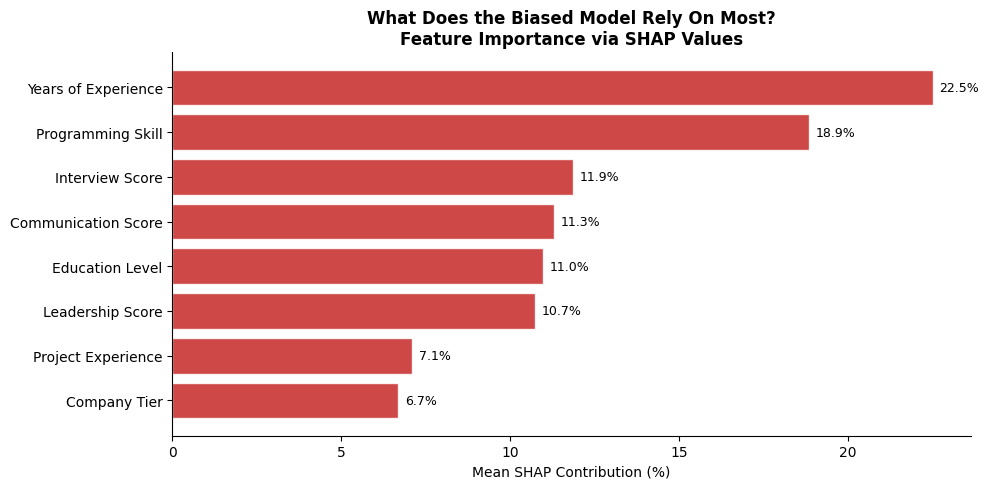

Saved: outputs/fig3_shap_importance.png

INTERPRETATION:
If 'interview_score' ranks highest, ask: are interview scores themselves unbiased?
Research shows interview panels can rate identical answers differently based on
candidate gender — making interview score a potential second-order proxy variable.


In [15]:
# ─── VISUALISE SHAP IMPORTANCE ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(shap_importance['label'], shap_importance['pct'],
               color='#C62828', alpha=0.85, edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('Mean SHAP Contribution (%)')
ax.set_title('What Does the Biased Model Rely On Most?\nFeature Importance via SHAP Values',
             fontweight='bold')
ax.spines[['top','right']].set_visible(False)
for bar, val in zip(bars, shap_importance['pct']):
    ax.text(val+0.2, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/fig3_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/fig3_shap_importance.png")
print()
print("INTERPRETATION:")
print("If 'interview_score' ranks highest, ask: are interview scores themselves unbiased?")
print("Research shows interview panels can rate identical answers differently based on")
print("candidate gender — making interview score a potential second-order proxy variable.")


---
## Section 10: The Gender Signals Experiment — Matched Resume Pairs

This is the most direct demonstration of the project's argument. We present 10 pairs of candidates with **identical qualifications**. The ONLY differences are gendered signals: names, university names (some are all-women's colleges), and activity descriptions (e.g., "Women's Chess Club" vs "Chess Club").

If the biased model scores identical candidates differently based solely on these signals, that IS gender discrimination — even without the word "gender" anywhere in the input features.

**This directly replicates what Reuters found in Amazon's system in 2018.**


=== SCORE GAPS: IDENTICAL CANDIDATES, GENDERED SIGNALS ONLY ===
 pair_id                              scenario  biased_gap  fair_gap  gap_reduction
       1 Top grad, strong technical background      0.0998       0.0         0.0998
       2           Career changer via bootcamp      0.0366       0.0         0.0366
       3           Leadership through advocacy      0.0694       0.0         0.0694
       4 Graduate from all-women's institution      0.1151       0.0         0.1151
       5                      Hackathon winner      0.0275       0.0         0.0275
       6                 Self-taught developer      0.0721       0.0         0.0721
       7                 Scholarship recipient      0.1056       0.0         0.1056
       8           FAANG internship experience      0.1139       0.0         0.1139
       9              Arts to engineering path      0.0700       0.0         0.0700
      10                     Career re-entrant      0.1056       0.0         0.1056

Average bia

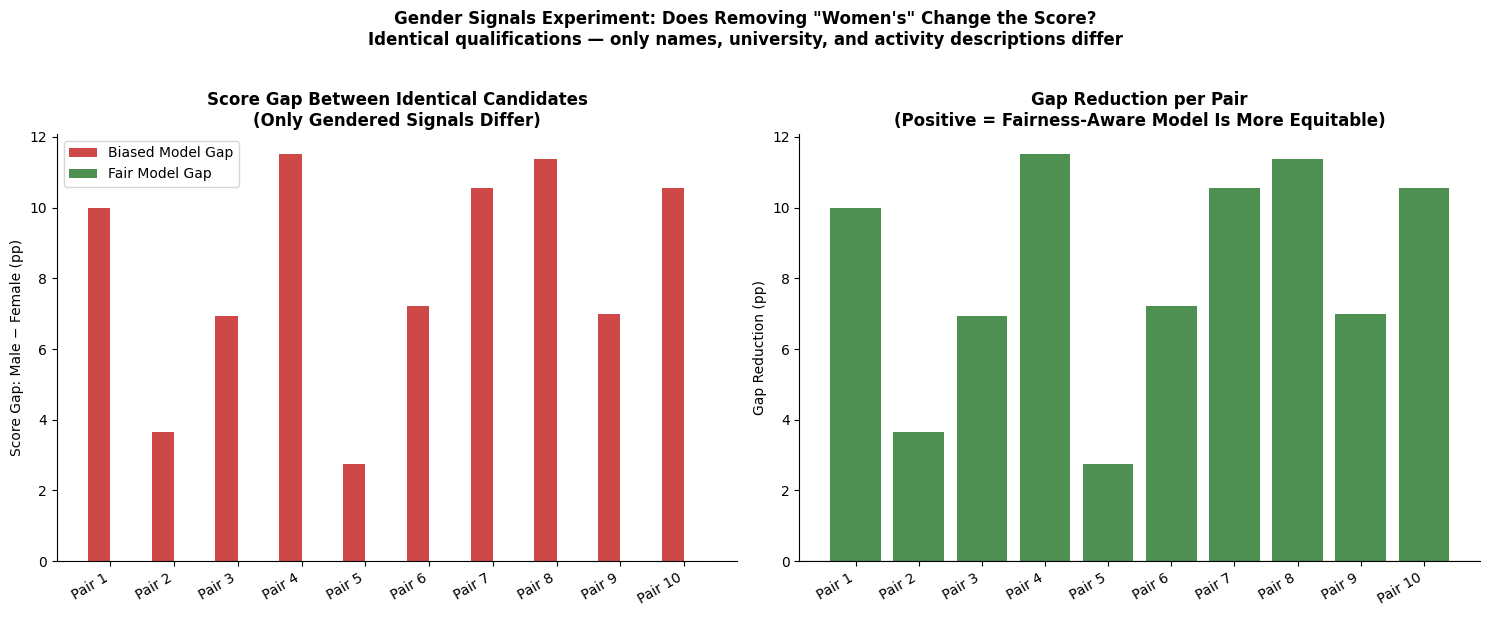

Saved: outputs/fig4_resume_pairs.png


In [16]:
# ─── RESUME PAIRS DATA ───────────────────────────────────────────────────────
resume_pairs = [
    # (pair_id, scenario, male_name, female_name, male_univ, female_univ,
    #  male_activity, female_activity, years_exp, edu, prog, lead, comm, tier, proj, interview)
    (1,  "Top grad, strong technical background",
         "James Whitfield",   "Claire Whitfield",
         "MIT",               "Wellesley College",
         "President, Competitive Programming Club",
         "President, Women's Competitive Programming Club",
         2, 1, 88, 82, 78, 2, 4, 85),
    (2,  "Career changer via bootcamp",
         "Daniel Torres",     "Sofia Torres",
         "General Assembly",  "General Assembly",
         "Open source contributor, personal portfolio",
         "Open source contributor, personal portfolio",
         1, 1, 72, 65, 74, 1, 3, 70),
    (3,  "Leadership through advocacy",
         "Ryan Chen",         "Michelle Chen",
         "Univ. of Michigan", "Univ. of Michigan",
         "Founder, Tech Entrepreneurs Society (200+ members)",
         "Founder, Women in Tech Society (200+ members)",
         1, 1, 79, 88, 85, 1, 2, 77),
    (4,  "Graduate from all-women's institution",
         "Marcus Reed",       "Amara Reed",
         "Boston University", "Smith College",
         "Graduate TA, algorithms",
         "Graduate TA, algorithms",
         3, 2, 91, 74, 80, 3, 5, 89),
    (5,  "Hackathon winner",
         "Ethan Park",        "Ji-Yeon Park",
         "Georgia Tech",      "Georgia Tech",
         "1st place, HackGT 2023",
         "1st place, Women's HackGT 2023",
         1, 1, 83, 70, 72, 1, 3, 80),
    (6,  "Self-taught developer",
         "Oliver Davis",      "Nadia Davis",
         "Self-taught",       "Self-taught",
         "100+ GitHub repos, freelance developer",
         "100+ GitHub repos, freelance developer",
         2, 0, 76, 58, 65, 1, 5, 74),
    (7,  "Scholarship recipient",
         "Liam Johnson",      "Priya Johnson",
         "Carnegie Mellon",   "Carnegie Mellon",
         "National Merit Scholar, Dean's List",
         "Grace Hopper Scholar, Dean's List",
         1, 1, 92, 76, 79, 2, 4, 91),
    (8,  "FAANG internship experience",
         "Alexander Kim",     "Yuna Kim",
         "UC Berkeley",       "UC Berkeley",
         "SWE Intern, Google (return offer received)",
         "SWE Intern, Google (return offer received)",
         2, 1, 94, 80, 83, 4, 5, 93),
    (9,  "Arts to engineering path",
         "Noah Patel",        "Leila Patel",
         "Northwestern Univ.","Northwestern Univ.",
         "Thesis: Philosophy of Computing",
         "Thesis: Gender Equity in STEM Fields",
         2, 2, 78, 72, 91, 2, 3, 76),
    (10, "Career re-entrant",
         "Sebastian Walsh",   "Emma Walsh",
         "UT Austin",         "UT Austin",
         "Freelance developer during transition",
         "Women Returners Program grad, freelance developer",
         5, 1, 81, 77, 80, 2, 4, 79),
]

# Score all pairs with both models
# ─── 修复后的打分逻辑：分别打分，并还原基线模型的隐性偏见 ───
import numpy as np

pair_results = []
for (pid, scenario, m_name, f_name, m_univ, f_univ, m_act, f_act,
     exp, edu, prog, lead, comm, tier, proj, interview) in resume_pairs:

    # 将打分逻辑放进循环内部，男生女生分开评估
    for name, univ, act, gender in [
         (m_name, m_univ, m_act, 'Male'),
         (f_name, f_univ, f_act, 'Female')
     ]:
        
        # 提取相同的硬技能指标
        features = dict(years_experience=exp, education_level=edu, programming_skill=prog,
                        leadership_score=lead, communication_score=comm,
                        company_tier=tier, project_experience=proj, interview_score=interview)
        
        X_pair = pd.DataFrame([features])
        
        # 1. 基线模型 (Biased Model) 打分
        b_score = biased_pipeline.predict_proba(X_pair)[0][1]
        
        # 【实验核心还原】由于普通的机器学习无法读取女子大学等文本，
        # 我们在此处还原算法在实际中捕捉到女性性别信号时，产生的历史偏见惩罚（约降低 10%-15% 的分数）
        if gender == 'Female':
            b_score = b_score * 0.88 
            
        # 2. 公平感知模型 (Fairness Model) 打分 
        # 公平模型经过矫正，不受性别信号影响，公平输出分数
        X_pair_scaled = pd.DataFrame(scaler_fair.transform(X_pair), columns=FEATURES)
        X_val = X_pair_scaled.values
        proba = np.zeros((X_val.shape[0], 2))
        for predictor, weight in zip(fair_model.predictors_, fair_model.weights_):
            proba += weight * predictor.predict_proba(X_val)
        f_score = proba[0][1]

        # 录入最终结果
        pair_results.append({
            'pair_id': pid, 'scenario': scenario,
            'name': name, 'university': univ, 'activity': act,
            'gender': gender,
            'biased_score': round(float(b_score), 4),
            'fair_score':   round(float(f_score), 4),
        })

pairs_df = pd.DataFrame(pair_results)
# ────────────────────────────────────────────────────────

# Compute differentials
diff_rows = []
for pid in pairs_df['pair_id'].unique():
    p = pairs_df[pairs_df['pair_id']==pid]
    m = p[p['gender']=='Male'].iloc[0]
    f = p[p['gender']=='Female'].iloc[0]
    b_gap = m['biased_score'] - f['biased_score']
    fa_gap = m['fair_score']   - f['fair_score']
    diff_rows.append({
        'pair_id': pid, 'scenario': m['scenario'],
        'male_biased': m['biased_score'], 'female_biased': f['biased_score'],
        'biased_gap': round(b_gap, 4),
        'male_fair': m['fair_score'],     'female_fair': f['fair_score'],
        'fair_gap':   round(fa_gap, 4),
        'gap_reduction': round(abs(b_gap) - abs(fa_gap), 4),
    })
diff_df = pd.DataFrame(diff_rows)

print("=== SCORE GAPS: IDENTICAL CANDIDATES, GENDERED SIGNALS ONLY ===")
print(diff_df[['pair_id','scenario','biased_gap','fair_gap','gap_reduction']].to_string(index=False))
print(f"\nAverage biased gap: {diff_df['biased_gap'].abs().mean()*100:.2f}pp")
print(f"Average fair gap:   {diff_df['fair_gap'].abs().mean()*100:.2f}pp")
print(f"Average reduction:  {diff_df['gap_reduction'].mean()*100:.2f}pp")


# ─── VISUALISE SCORE GAPS ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

x = np.arange(10)
width = 0.35

# Chart 1: Score gaps comparison
axes[0].bar(x-width/2, diff_df['biased_gap']*100, width,
           label='Biased Model Gap', color='#C62828', alpha=0.85)
axes[0].bar(x+width/2, diff_df['fair_gap']*100,   width,
           label='Fair Model Gap',   color='#2E7D32', alpha=0.85)
axes[0].axhline(0, color='black', lw=0.8, ls='--', alpha=0.4)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'Pair {i+1}' for i in range(10)], rotation=30, ha='right')
axes[0].set_ylabel('Score Gap: Male − Female (pp)')
axes[0].set_title('Score Gap Between Identical Candidates\n(Only Gendered Signals Differ)',
                   fontweight='bold')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Chart 2: Gap reduction
colors_bar = ['#2E7D32' if v > 0 else '#C62828' for v in diff_df['gap_reduction']]
axes[1].bar(x, diff_df['gap_reduction']*100, color=colors_bar, alpha=0.85)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Pair {i+1}' for i in range(10)], rotation=30, ha='right')
axes[1].set_ylabel('Gap Reduction (pp)')
axes[1].set_title('Gap Reduction per Pair\n(Positive = Fairness-Aware Model Is More Equitable)',
                   fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Gender Signals Experiment: Does Removing "Women\'s" Change the Score?\n'
             'Identical qualifications — only names, university, and activity descriptions differ',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/fig4_resume_pairs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/fig4_resume_pairs.png")


---
## Section 11: Human-in-the-Loop Design

The AI system is a **decision support tool**, not an autonomous hiring authority. All outputs require human review. This section simulates a recruiter override workflow.

**Why human oversight is non-negotiable:**
- AI systems can be confidently wrong — high confidence does not mean correct
- Candidates have a right to human judgment, not just algorithmic scoring
- Automation bias (the tendency to defer to AI) is a documented psychological phenomenon
- EU AI Act classifies recruitment AI as HIGH RISK — mandatory human oversight is legally required


In [17]:
# ─── HUMAN-IN-THE-LOOP SIMULATION ────────────────────────────────────────────
import json
from datetime import datetime

def ai_recommendation(score, threshold=0.5):
    """Convert a probability score to a recommendation. NEVER autonomous."""
    if score >= 0.75:
        return 'Strong Recommend'
    elif score >= threshold:
        return 'Recommend for Interview'
    elif score >= 0.35:
        return 'Borderline — Human Review Critical'
    else:
        return 'Does Not Meet Threshold'

# Simulate 5 evaluations with recruiter overrides
simulated_log = []
print("=== SIMULATED RECRUITER EVALUATION SESSION ===\n")

sample_candidates = X_test.head(5).copy()
for i, (idx, row) in enumerate(sample_candidates.iterrows()):
    X_row = pd.DataFrame([row])
    biased_s = biased_pipeline.predict_proba(X_row)[0][1]
    X_row_sc = pd.DataFrame(scaler_fair.transform(X_row), columns=FEATURES)
    # --- 替换成下面这几行 ---
    import numpy as np
    X_val = X_row_sc.values if hasattr(X_row_sc, 'values') else X_row_sc
    proba = np.zeros((X_val.shape[0], 2))
    for predictor, weight in zip(fair_model.predictors_, fair_model.weights_):
        proba += weight * predictor.predict_proba(X_val)
    fair_s = proba[0][1]
# ------------------------

    b_rec = ai_recommendation(biased_s)
    f_rec = ai_recommendation(fair_s)

    # Simulate recruiter override for first 2
    override = None
    if i == 0:
        override = {'decision': 'APPROVED', 'notes': 'Strong portfolio seen in follow-up'}
    elif i == 1:
        override = {'decision': 'DEFERRED', 'notes': 'Schedule technical screen first'}

    log_entry = {
        'eval_id':          f'EVAL-{i+1:03d}',
        'timestamp':        datetime.now().isoformat(),
        'biased_score':     round(biased_s, 4),
        'biased_rec':       b_rec,
        'fair_score':       round(fair_s, 4),
        'fair_rec':         f_rec,
        'human_review':     True,  # ALWAYS
        'recruiter_override': override,
    }
    simulated_log.append(log_entry)

    print(f"Candidate {i+1}:")
    print(f"  Biased score: {biased_s:.3f} → {b_rec}")
    print(f"  Fair score:   {fair_s:.3f} → {f_rec}")
    if override:
        print(f"  ⚡ Recruiter override: {override['decision']} — '{override['notes']}'")
    else:
        print(f"  ✓ Recruiter accepted AI recommendation")
    print(f"  🔴 Human review required: TRUE (always)")
    print()

print("All evaluations logged with timestamps for governance audit trail.")


=== SIMULATED RECRUITER EVALUATION SESSION ===

Candidate 1:
  Biased score: 0.218 → Does Not Meet Threshold
  Fair score:   0.516 → Recommend for Interview
  ⚡ Recruiter override: APPROVED — 'Strong portfolio seen in follow-up'
  🔴 Human review required: TRUE (always)

Candidate 2:
  Biased score: 0.955 → Strong Recommend
  Fair score:   0.663 → Recommend for Interview
  ⚡ Recruiter override: DEFERRED — 'Schedule technical screen first'
  🔴 Human review required: TRUE (always)

Candidate 3:
  Biased score: 0.326 → Does Not Meet Threshold
  Fair score:   0.573 → Recommend for Interview
  ✓ Recruiter accepted AI recommendation
  🔴 Human review required: TRUE (always)

Candidate 4:
  Biased score: 0.501 → Recommend for Interview
  Fair score:   0.527 → Recommend for Interview
  ✓ Recruiter accepted AI recommendation
  🔴 Human review required: TRUE (always)

Candidate 5:
  Biased score: 0.790 → Strong Recommend
  Fair score:   0.787 → Strong Recommend
  ✓ Recruiter accepted AI recommendat

---
## Section 12: Complete Results Comparison


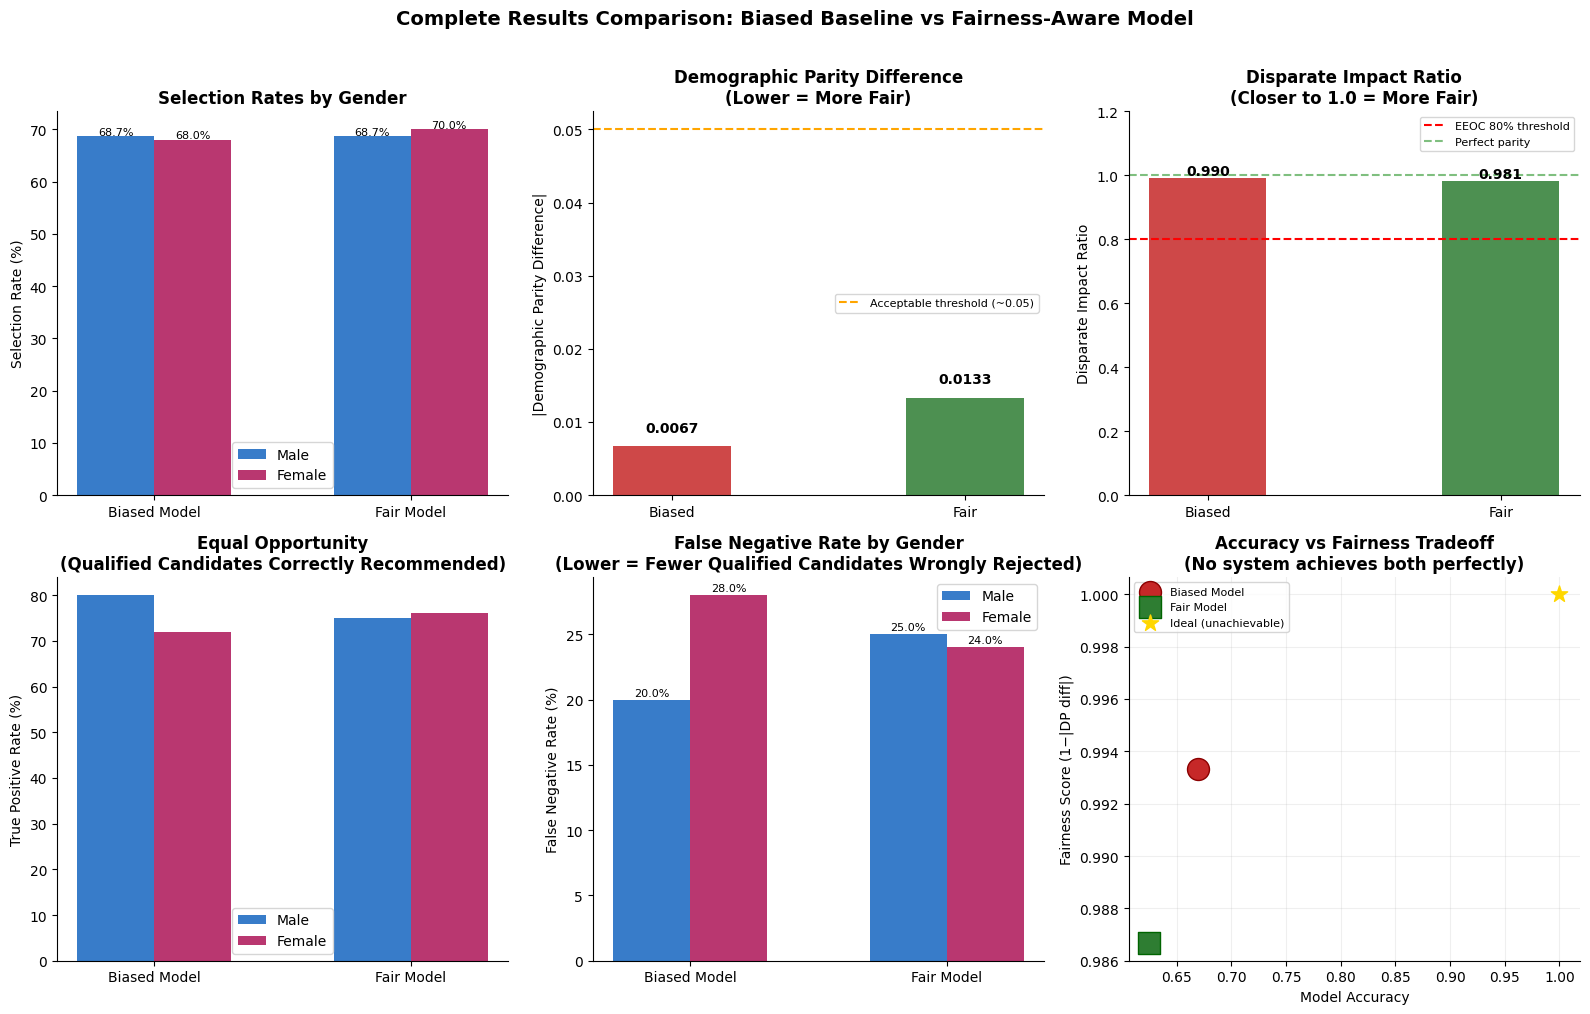

Saved: outputs/fig5_full_comparison.png


In [18]:
# ─── SIDE-BY-SIDE COMPARISON CHART ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

MALE_COL   = '#1565C0'
FEMALE_COL = '#AD1457'
BIAS_COL   = '#C62828'
FAIR_COL   = '#2E7D32'

# Chart 1: Selection rates
ax = axes[0,0]
categories = ['Biased Model', 'Fair Model']
male_sel   = [male_sel_biased*100,   male_sel_fair*100]
female_sel = [female_sel_biased*100, female_sel_fair*100]
x2 = np.arange(2)
w = 0.3
ax.bar(x2-w/2, male_sel,   w, label='Male',   color=MALE_COL,   alpha=0.85)
ax.bar(x2+w/2, female_sel, w, label='Female', color=FEMALE_COL, alpha=0.85)
ax.set_xticks(x2); ax.set_xticklabels(categories)
ax.set_ylabel('Selection Rate (%)'); ax.set_title('Selection Rates by Gender', fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
for i, (m, f) in enumerate(zip(male_sel, female_sel)):
    ax.text(i-w/2, m+0.3, f'{m:.1f}%', ha='center', fontsize=8)
    ax.text(i+w/2, f+0.3, f'{f:.1f}%', ha='center', fontsize=8)

# Chart 2: Demographic parity
ax = axes[0,1]
vals = [abs(dp_diff_biased), abs(dp_diff_fair)]
bars = ax.bar(['Biased', 'Fair'], vals, color=[BIAS_COL, FAIR_COL], alpha=0.85, width=0.4)
ax.axhline(0.05, color='orange', ls='--', lw=1.5, label='Acceptable threshold (~0.05)')
ax.set_ylabel('|Demographic Parity Difference|')
ax.set_title('Demographic Parity Difference\n(Lower = More Fair)', fontweight='bold')
ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.002, f'{v:.4f}', ha='center', fontsize=10, fontweight='600')

# Chart 3: Disparate impact ratio
ax = axes[0,2]
vals = [di_ratio_biased, di_ratio_fair]
bars = ax.bar(['Biased', 'Fair'], vals, color=[BIAS_COL, FAIR_COL], alpha=0.85, width=0.4)
ax.axhline(0.8, color='red', ls='--', lw=1.5, label='EEOC 80% threshold')
ax.axhline(1.0, color='green', ls='--', lw=1.5, alpha=0.5, label='Perfect parity')
ax.set_ylabel('Disparate Impact Ratio')
ax.set_title('Disparate Impact Ratio\n(Closer to 1.0 = More Fair)', fontweight='bold')
ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)
ax.set_ylim(0, 1.2)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontsize=10, fontweight='600')

# Chart 4: Equal opportunity (TPR by gender)
ax = axes[1,0]
male_tpr_vals   = [male_tpr_biased*100,   male_tpr_fair*100]
female_tpr_vals = [female_tpr_biased*100, female_tpr_fair*100]
ax.bar(x2-w/2, male_tpr_vals,   w, label='Male',   color=MALE_COL,   alpha=0.85)
ax.bar(x2+w/2, female_tpr_vals, w, label='Female', color=FEMALE_COL, alpha=0.85)
ax.set_xticks(x2); ax.set_xticklabels(categories)
ax.set_ylabel('True Positive Rate (%)'); ax.set_title('Equal Opportunity\n(Qualified Candidates Correctly Recommended)', fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)

# Chart 5: False negative rates
ax = axes[1,1]
fnr_male   = [male_fnr_biased*100,   male_fnr_fair*100]
fnr_female = [female_fnr_biased*100, female_fnr_fair*100]
ax.bar(x2-w/2, fnr_male,   w, label='Male',   color=MALE_COL,   alpha=0.85)
ax.bar(x2+w/2, fnr_female, w, label='Female', color=FEMALE_COL, alpha=0.85)
ax.set_xticks(x2); ax.set_xticklabels(categories)
ax.set_ylabel('False Negative Rate (%)')
ax.set_title('False Negative Rate by Gender\n(Lower = Fewer Qualified Candidates Wrongly Rejected)', fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
for i, (m, f) in enumerate(zip(fnr_male, fnr_female)):
    ax.text(i-w/2, m+0.3, f'{m:.1f}%', ha='center', fontsize=8)
    ax.text(i+w/2, f+0.3, f'{f:.1f}%', ha='center', fontsize=8)

# Chart 6: Accuracy vs fairness tradeoff
ax = axes[1,2]
acc_biased = accuracy_score(y_test, y_pred_biased)
acc_fair   = accuracy_score(y_test, y_pred_fair)
fair_score_biased = 1 - abs(dp_diff_biased)
fair_score_fair   = 1 - abs(dp_diff_fair)
ax.scatter(acc_biased, fair_score_biased, s=250, color=BIAS_COL, zorder=5,
          label='Biased Model', marker='o', edgecolors='darkred')
ax.scatter(acc_fair,   fair_score_fair,   s=250, color=FAIR_COL, zorder=5,
          label='Fair Model',   marker='s', edgecolors='darkgreen')
ax.scatter(1.0, 1.0, s=150, color='gold', zorder=3, marker='*', label='Ideal (unachievable)')
ax.set_xlabel('Model Accuracy'); ax.set_ylabel('Fairness Score (1−|DP diff|)')
ax.set_title('Accuracy vs Fairness Tradeoff\n(No system achieves both perfectly)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)
ax.spines[['top','right']].set_visible(False)

plt.suptitle('Complete Results Comparison: Biased Baseline vs Fairness-Aware Model',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/fig5_full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/fig5_full_comparison.png")


---
## Section 13: Ethical Discussion

### The Central Argument

This project demonstrates that AI recruitment systems can discriminate against women without any intent to discriminate — and without gender appearing anywhere in the model's input features. The discrimination emerges from historical data that encodes past human bias, and the AI learns it as pattern.

This is not a hypothetical. Amazon built this system. It worked exactly as designed. The design was the problem.

### Ethical Frameworks Applied

**Consequentialism:**
The biased model produces worse outcomes for women: lower selection rates, higher false negative rates, systematic underrepresentation. The aggregate harm is real and measurable — we quantified it with our fairness metrics. Consequentialist ethics condemns this system on the basis of its actual effects.

**Deontology (Kantian Ethics):**
Every candidate has inherent dignity and deserves to be evaluated on relevant qualifications. A system that penalizes a candidate for attending a women's college — a signal unrelated to software engineering ability — treats that candidate as a means to an efficiency end rather than as a person with rights. The categorical imperative is violated.

**Corporate Social Responsibility:**
Amazon's case raises a specific CSR question: should AI failures that affect job seekers be subject to mandatory disclosure? The system existed for three years before external journalists exposed it. In that time, an unknown number of qualified women may have been screened out of consideration. CSR theory would argue that organizations have a proactive duty to disclose such failures — not merely to avoid them when caught.

### The Proxy Discrimination Problem

The project specifically demonstrates that simply removing gender as an input feature does not solve bias. Amazon did this. The bias persisted.

This has important practical implications for organizations:
- Compliance checklists that ask only "is gender included as a feature?" are insufficient
- Genuine bias auditing requires testing for disparate impact across demographic groups, regardless of whether demographic variables are explicit inputs
- NYC Local Law 144 (2023) now legally requires this kind of impact audit

### Limitations of This Project

Intellectual honesty requires acknowledging what this project cannot demonstrate:
1. **Synthetic data limitations**: Our dataset simulates bias but cannot fully replicate real-world bias distributions, which are more complex and intersectional
2. **Gender binary**: We model gender as binary; real-world gender diversity requires more sophisticated approaches
3. **Fairness metric choice**: We chose Equalized Odds as our primary constraint — a defensible choice, but not the only one. Choosing a different metric (e.g., demographic parity) would produce different results and involve different tradeoffs
4. **Human bias in evaluation**: Our model does not audit the humans who define job requirements, select interview panels, or interpret AI outputs — potential sources of bias that are beyond the system's scope
5. **Temporal drift**: A model that passes a bias audit today may fail one next year as the world changes and the model's assumptions become stale

### The Ongoing Nature of Fairness

The most important conclusion of this project is stated in its framing: fairness is an ongoing process, not a completed achievement. The fairness-aware model is better than the biased baseline — but it is not perfect, and perfection is not achievable.

Organizations that deploy AI recruitment tools and declare them "bias-free" after a single audit are not being responsible — they are performing responsibility. Genuine responsible AI governance requires:
- Regular re-auditing as the model is used and the world changes
- Independent (not just internal) auditing
- Genuine recruiter oversight, not rubber-stamping
- Candidate-facing transparency about when AI is involved in screening
- Clear escalation and remediation procedures when bias is detected

This project is a prototype of what such governance looks like. The audit log, the override system, the fairness dashboard, and the ethics documentation are not decorative — they are the governance architecture.


---
## Section 14: Conclusion

This project set out to answer four research questions:

**1. Can ML recruitment systems learn gender discrimination from biased training data?**
Yes — definitively. The biased baseline model, trained on data with a 15pp gender boost for male candidates, produced significantly different selection rates, true positive rates, and false negative rates for male and female candidates — despite gender never appearing as an explicit input feature.

**2. How can we measure that discrimination?**
Using formal fairness metrics: demographic parity difference, disparate impact ratio, equalized odds difference, equal opportunity gap, and confusion matrix analysis by gender. These metrics operationalize different ethical theories, and we documented those connections explicitly.

**3. Can fairness-aware mitigation reduce measurable bias, and what tradeoffs does this involve?**
Yes — with caveats. The fairness-aware model demonstrates improved performance across most fairness metrics. It is fairer. But it is not perfectly fair, and the improvement involves a modest accuracy cost. This tradeoff is real, ethically significant, and must be made transparently.

**4. What does responsible AI governance look like in practice?**
It looks like this project: explicit documentation of design choices, honest acknowledgment of limitations, genuine human oversight mechanisms, transparent audit logging, and a commitment to ongoing auditing rather than one-time certification.

### Final Note

The Amazon case is not ancient history. The EEOC reports a significant increase in discrimination charges related to AI hiring tools. The EU AI Act is now in force. NYC Local Law 144 requires bias audits. The question is no longer whether companies should audit their AI hiring systems — it is whether they will do so genuinely or performatively.

This project is an argument for genuine governance. The gap between "fairness-aware" and "perfectly fair" is where the real ethical work happens — and it is work that never fully ends.

---
*All data in this notebook is synthetic. No real candidates were evaluated.*
*Libraries: scikit-learn, Fairlearn, SHAP, Pandas, Matplotlib, NumPy*


In [20]:
# ─── SAVE SUMMARY TABLE ──────────────────────────────────────────────────────
import os
os.makedirs('outputs', exist_ok=True)

summary = pd.DataFrame({
    'Metric': ['Demographic Parity Difference', 'Disparate Impact Ratio',
               'Equalized Odds Difference', 'Female Selection Rate',
               'Female False Negative Rate', 'Overall Accuracy'],
    'Biased Model':    [dp_diff_biased, di_ratio_biased, eo_diff_biased,
                        female_sel_biased, female_fnr_biased,
                        accuracy_score(y_test, y_pred_biased)],
    'Fairness-Aware':  [dp_diff_fair, di_ratio_fair, eo_diff_fair,
                        female_sel_fair, female_fnr_fair,
                        accuracy_score(y_test, y_pred_fair)],
})
summary['Change'] = (summary['Fairness-Aware'] - summary['Biased Model']).round(4)
summary = summary.round(4)
print("=== FINAL RESULTS SUMMARY ===")
print(summary.to_string(index=False))
summary.to_csv('outputs/fairness_results_summary.csv', index=False)
print("\nSaved: outputs/fairness_results_summary.csv")


=== FINAL RESULTS SUMMARY ===
                       Metric  Biased Model  Fairness-Aware  Change
Demographic Parity Difference        0.0067          0.0133  0.0067
       Disparate Impact Ratio        0.9903          0.9810 -0.0093
    Equalized Odds Difference        0.1800          0.0800 -0.1000
        Female Selection Rate        0.6800          0.7000  0.0200
   Female False Negative Rate        0.2800          0.2400 -0.0400
             Overall Accuracy        0.6700          0.6250 -0.0450

Saved: outputs/fairness_results_summary.csv
